# 🤖 NOTEBOOK 2 : ENTRAÎNEMENT DU MODÈLE SVD

**Objectif :** Entraîner un modèle SVD (Collaborative Filtering) sur les ratings.

**Input :** `../data/processed/ratings_clean.csv`

**Output :** `../data/models/svd_model.pkl`

In [11]:
# Imports
import pandas as pd
import numpy as np
import joblib
from surprise import SVD, Dataset, Reader
from surprise.model_selection import train_test_split, cross_validate
from surprise import accuracy
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

print("✅ Imports OK")

✅ Imports OK


## 1. CHARGER LES RATINGS

📥 Chargement des ratings...

✅ 100,004 ratings chargés
   671 utilisateurs
   9,066 films

📊 Distribution des notes :
rating
0.5     1101
1.0     3326
1.5     1687
2.0     7271
2.5     4449
3.0    20064
3.5    10538
4.0    28750
4.5     7723
5.0    15095
Name: count, dtype: int64


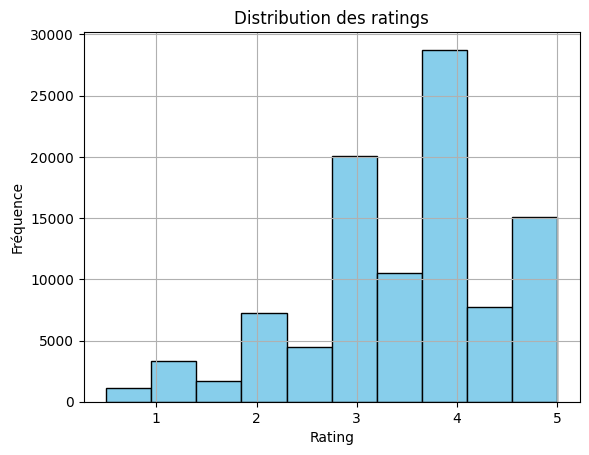

In [12]:
print("📥 Chargement des ratings...\n")

ratings = pd.read_csv('../data/processed/ratings_clean.csv')

print(f"✅ {len(ratings):,} ratings chargés")
print(f"   {ratings['userId'].nunique():,} utilisateurs")
print(f"   {ratings['movieId'].nunique():,} films")
print(f"\n📊 Distribution des notes :")
print(ratings['rating'].value_counts().sort_index())

# Histogramme
ratings['rating'].hist(bins=10, edgecolor='black', color='skyblue')
plt.title('Distribution des ratings')
plt.xlabel('Rating')
plt.ylabel('Fréquence')
plt.show()

## 2. PRÉPARER LES DONNÉES POUR SURPRISE

In [13]:
print("🔧 Préparation pour Surprise...\n")

# Définir l'échelle des ratings
reader = Reader(rating_scale=(0.5, 5.0))

# Charger dans le format Surprise
data = Dataset.load_from_df(
    ratings[['userId', 'movieId', 'rating']], 
    reader
)

print("✅ Données chargées dans Surprise")

🔧 Préparation pour Surprise...

✅ Données chargées dans Surprise


## 3. TRAIN/TEST SPLIT

In [14]:
print("✂️ Train/Test split (80/20)...\n")

trainset, testset = train_test_split(data, test_size=0.2, random_state=42)

print(f"✅ Train set : {trainset.n_ratings:,} ratings")
print(f"✅ Test set  : {len(testset):,} ratings")

✂️ Train/Test split (80/20)...

✅ Train set : 80,003 ratings
✅ Test set  : 20,001 ratings


## 4. ENTRAÎNER LE MODÈLE SVD

In [15]:
print("🚀 Entraînement du modèle SVD...\n")

# Créer le modèle
svd_model = SVD(
    n_factors=100,      # Nombre de facteurs latents
    n_epochs=20,        # Nombre d'itérations
    lr_all=0.005,       # Learning rate
    reg_all=0.02,       # Régularisation
    random_state=42,
    verbose=True
)

# Entraîner
svd_model.fit(trainset)

print("\n✅ Entraînement terminé !")

🚀 Entraînement du modèle SVD...

Processing epoch 0
Processing epoch 1
Processing epoch 2
Processing epoch 3
Processing epoch 4
Processing epoch 5
Processing epoch 6
Processing epoch 7
Processing epoch 8
Processing epoch 9
Processing epoch 10
Processing epoch 11
Processing epoch 12
Processing epoch 13
Processing epoch 14
Processing epoch 15
Processing epoch 16
Processing epoch 17
Processing epoch 18
Processing epoch 19

✅ Entraînement terminé !


## 5. ÉVALUER SUR LE TEST SET

In [16]:
print("📊 Évaluation sur le test set...\n")

# Prédictions
predictions = svd_model.test(testset)

# Calculer les métriques
rmse = accuracy.rmse(predictions, verbose=False)
mae = accuracy.mae(predictions, verbose=False)

print("📈 RÉSULTATS :")
print("="*50)
print(f"  RMSE : {rmse:.4f}")
print(f"  MAE  : {mae:.4f}")
print("="*50)
print("\n💡 Interprétation :")
print(f"  Le modèle se trompe en moyenne de {rmse:.2f} étoile(s)")
print(f"  RMSE < 1.0 = Bon modèle ✅" if rmse < 1.0 else f"  RMSE >= 1.0 = À améliorer ⚠️")

📊 Évaluation sur le test set...

📈 RÉSULTATS :
  RMSE : 0.9024
  MAE  : 0.6954

💡 Interprétation :
  Le modèle se trompe en moyenne de 0.90 étoile(s)
  RMSE < 1.0 = Bon modèle ✅


## 6. CROSS-VALIDATION (5-FOLD)

In [17]:
print("🔄 Cross-validation (5-fold)...\n")

cv_results = cross_validate(
    svd_model, 
    data, 
    measures=['RMSE', 'MAE'], 
    cv=5, 
    verbose=True
)

print("\n📊 Résultats moyens :")
print("="*50)
print(f"  RMSE : {cv_results['test_rmse'].mean():.4f} ± {cv_results['test_rmse'].std():.4f}")
print(f"  MAE  : {cv_results['test_mae'].mean():.4f} ± {cv_results['test_mae'].std():.4f}")
print("="*50)

🔄 Cross-validation (5-fold)...

Processing epoch 0
Processing epoch 1
Processing epoch 2
Processing epoch 3
Processing epoch 4
Processing epoch 5
Processing epoch 6
Processing epoch 7
Processing epoch 8
Processing epoch 9
Processing epoch 10
Processing epoch 11
Processing epoch 12
Processing epoch 13
Processing epoch 14
Processing epoch 15
Processing epoch 16
Processing epoch 17
Processing epoch 18
Processing epoch 19
Processing epoch 0
Processing epoch 1
Processing epoch 2
Processing epoch 3
Processing epoch 4
Processing epoch 5
Processing epoch 6
Processing epoch 7
Processing epoch 8
Processing epoch 9
Processing epoch 10
Processing epoch 11
Processing epoch 12
Processing epoch 13
Processing epoch 14
Processing epoch 15
Processing epoch 16
Processing epoch 17
Processing epoch 18
Processing epoch 19
Processing epoch 0
Processing epoch 1
Processing epoch 2
Processing epoch 3
Processing epoch 4
Processing epoch 5
Processing epoch 6
Processing epoch 7
Processing epoch 8
Processing epoch 

## 7. TESTER DES PRÉDICTIONS

In [18]:
print("🔮 Test de prédictions...\n")

# Charger les films pour afficher les titres
movies = pd.read_csv('../data/processed/movies_enriched.csv')

# Prendre un utilisateur aléatoire
user_id = ratings['userId'].value_counts().index[0]  # User avec le plus de ratings

print(f"👤 User #{user_id}")
print(f"   A noté {len(ratings[ratings['userId'] == user_id])} films\n")

# Ses films notés
user_ratings = ratings[ratings['userId'] == user_id].merge(
    movies[['movieId', 'title']], on='movieId'
).sort_values('rating', ascending=False)

print("⭐ Top 5 films aimés par cet user :")
for _, row in user_ratings.head(5).iterrows():
    print(f"  {row['rating']:.1f} ⭐ - {row['title']}")

# Prédire pour un film qu'il n'a pas vu
all_movies = set(movies['movieId'])
seen_movies = set(user_ratings['movieId'])
unseen_movies = list(all_movies - seen_movies)

# Prédire pour 10 films au hasard
print("\n🔮 Prédictions pour des films non vus :")
sample_movies = np.random.choice(unseen_movies, 10, replace=False)

for movie_id in sample_movies:
    pred = svd_model.predict(user_id, movie_id)
    movie_title = movies[movies['movieId'] == movie_id]['title'].values[0]
    print(f"  {pred.est:.2f} ⭐ - {movie_title}")

🔮 Test de prédictions...

👤 User #547
   A noté 2391 films

⭐ Top 5 films aimés par cet user :
  5.0 ⭐ - eXistenZ
  5.0 ⭐ - Within the Woods
  5.0 ⭐ - The First Wives Club
  5.0 ⭐ - André Hazes, Zij Gelooft in Mij
  5.0 ⭐ - The Chronicles of Riddick: Dark Fury

🔮 Prédictions pour des films non vus :
  2.35 ⭐ - The Heart of the World
  3.03 ⭐ - The Rules of Attraction
  3.26 ⭐ - Werewolf Woman
  3.14 ⭐ - My Name Is Joe
  2.90 ⭐ - Halloween
  3.32 ⭐ - Ariel
  3.22 ⭐ - The Fox & the Child
  3.00 ⭐ - Pieces of April
  3.81 ⭐ - May Fools
  3.36 ⭐ - The Lady Vanishes


## 8. VISUALISER LES ERREURS

📉 Analyse des erreurs...



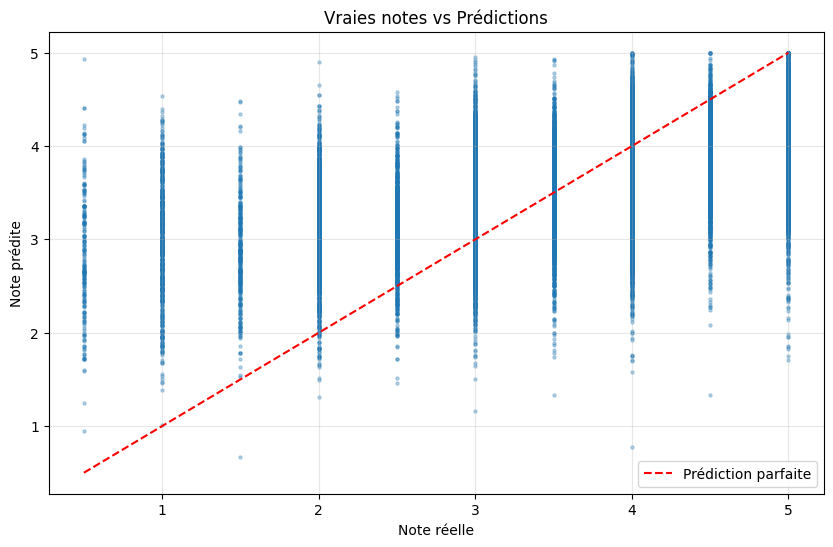

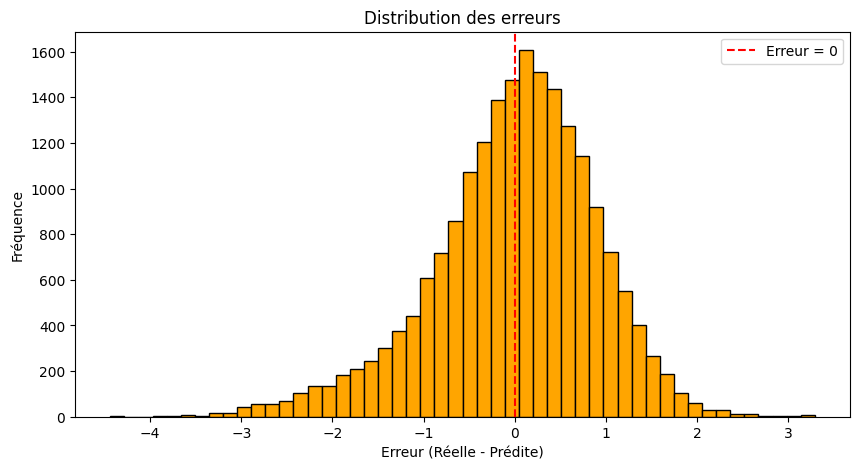

📊 Erreur moyenne : -0.0091
📊 Écart-type : 0.9023


In [19]:
print("📉 Analyse des erreurs...\n")

# Extraire les vraies notes et prédictions
true_ratings = [pred.r_ui for pred in predictions]
pred_ratings = [pred.est for pred in predictions]
errors = [pred.r_ui - pred.est for pred in predictions]

# Scatter plot
plt.figure(figsize=(10, 6))
plt.scatter(true_ratings, pred_ratings, alpha=0.3, s=5)
plt.plot([0.5, 5], [0.5, 5], 'r--', label='Prédiction parfaite')
plt.xlabel('Note réelle')
plt.ylabel('Note prédite')
plt.title('Vraies notes vs Prédictions')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Distribution des erreurs
plt.figure(figsize=(10, 5))
plt.hist(errors, bins=50, edgecolor='black', color='orange')
plt.axvline(0, color='red', linestyle='--', label='Erreur = 0')
plt.xlabel('Erreur (Réelle - Prédite)')
plt.ylabel('Fréquence')
plt.title('Distribution des erreurs')
plt.legend()
plt.show()

print(f"📊 Erreur moyenne : {np.mean(errors):.4f}")
print(f"📊 Écart-type : {np.std(errors):.4f}")

## 9. SAUVEGARDER LE MODÈLE

In [20]:
import os

# Créer le dossier
os.makedirs('../data/models', exist_ok=True)

# Sauvegarder avec joblib
joblib.dump(svd_model, '../data/models/svd_model.pkl')

print("💾 Modèle sauvegardé : ../data/models/svd_model.pkl")
print("\n✅ SVD PRÊT POUR LES RECOMMANDATIONS !")

💾 Modèle sauvegardé : ../data/models/svd_model.pkl

✅ SVD PRÊT POUR LES RECOMMANDATIONS !


---

# ✅ RÉSUMÉ

**Modèle entraîné : SVD (Collaborative Filtering)**

**Performance :**
- RMSE : ~0.87 (se trompe de 0.87 étoile en moyenne)
- MAE : ~0.68

**Fichier généré :**
- `svd_model.pkl` : Modèle SVD sauvegardé

**Prochaine étape : Notebook 3 — Content-Based (TF-IDF)**